### 데이터 분석

1.  데이터 수집
  - 기간을 두고 업체 또는 개인이 직접 수집
  - 데이터 제공하는 기관으로부터 받아오기 (통계청, 공공데이터, 기업 오픈 데이터 등)
  - open API, 크롤링
  - 파일로 저장 / 데이터베이스 서버 구축 후 저장(MySQL, OracleDB, MSSQL, JSON, MariaDB, MongoDB)

2. 데이터 저장
  - 저장소에 저장 방법(실시간 또는 일정 기간 단위)

3. 전처리
  - 분석에 적합한 데이터 구성으로 만드는 작업

4. 분석
  - 다양한 분석 방법을 통해 분석

## 네이버 지식인 검색 결과 분석 (제주도)

In [ ]:
# 글꼴 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 설치 완료 후 반드시 런타임 재시작

1. 데이터 파일 업로드
  - 코랩의 가상 디스크에 파일 업로드

In [ ]:
from google.colab import files
myfile = files.upload()

Saving 제주도_지식인.csv to 제주도_지식인 (1).csv


구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 작업할 폴더로 이동
%cd /content/drive/MyDrive/Multi

/content/drive/MyDrive/Multi


In [ ]:
!pwd # 현재 작업중인 폴더 위치 확인

/content/drive/MyDrive/Multi


In [ ]:
# 하위 폴더 및 현재 폴더에 있는 파일 확인
!ls

 함수					     if문.ipynb
'사용자 정의 함수'			     python_basic
 반복문					     python_class
 라이브러리				    'QR코드 생성 및 파일 읽기'
'1. for 한줄쓰기 및 에러처리.ipynb'	     qr_daum.png
 202202_mf.csv				     qr_google.png
'코랩 환경 설정_220330.ipynb'		     qrimg
 관광정보.csv				     qr_nate.png
 data					     qr_naver.png
'모듈 설치 및 for문으로 메일 보내기.ipynb'   qr_site.txt
 관광맵.html


In [ ]:
filename = '/content/제주도_지식인.csv'

2. pandas 모듈을 이용해 데이터를 읽어오기

In [ ]:
import pandas as pd

In [ ]:
# 구글 드라이브에 있는 데이터 읽어오기
df = pd.read_csv('/content/제주도_지식인.csv')
df.head(1)

,title,link,description,질문,답변
0,<b>제주도</b> 신혼여행 질문입니다.,https://kin.naver.com/qna/detail.naver?d1id=9&...,... 신혼여행을 5월1일날 <b>제주도</b>로 가게되었는데 그때의 <b>제주도<...,4월에 결혼식을 앞둔 예비신랑입니다. 신혼여행을 5월1일날 제주도로 가게되었는데그때...,건강한 사람이라면 반팔에 바람막이 얇은 옷 하나 들고 가세요접으면 주먹만한 ...


3. 데이터 전처리

In [ ]:
# 데이터 구성 요소 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        1000 non-null   object
 1   link         1000 non-null   object
 2   description  1000 non-null   object
 3   질문           1000 non-null   object
 4   답변           975 non-null    object
dtypes: object(5)
memory usage: 39.2+ KB


In [ ]:
# 불필요한 열 삭제하기 (description)

# 삭제할 열이 1개 일때
del df['description'] # 실행 즉시 삭제

# 삭제할 데이터가 많은 경우(loc[], iloc[] 사용)
#df=df.loc[:,['title','link','질문','답변']]
#df=df.iloc[:,[0,1,3,4]]

In [ ]:
# 열 이름 확인
df.columns

Index(['title', 'link', '질문', '답변'], dtype='object')

In [ ]:
# 열 이름 변경
df.columns = ['title', 'link','question','answer']
df.columns

Index(['title', 'link', 'question', 'answer'], dtype='object')

### NaN 값 삭제

In [ ]:
# 데이터의 NaN 값 건수 확인하기
df.isna().sum()

title        0
link         0
question     0
answer      25
dtype: int64

In [ ]:
# NaN 데이터가 포함되어 있는 행 전체 삭제 (적용하려면 df=drop()/df.drop())
df.dropna() # NaN이 1개라도 포함되어 있으면 해당 행 삭제
df.dropna(subset=['answer']) # answer에 NaN이 있으면 행 전체 삭제
#df.dropna(axis=1) # NaN이 포함된 열 전체 삭제

,title,link,question,answer
0,<b>제주도</b> 신혼여행 질문입니다.,https://kin.naver.com/qna/detail.naver?d1id=9&...,4월에 결혼식을 앞둔 예비신랑입니다. 신혼여행을 5월1일날 제주도로 가게되었는데그때...,건강한 사람이라면 반팔에 바람막이 얇은 옷 하나 들고 가세요접으면 주먹만한 ...
1,<b>제주도</b> 3박4일 여행코스,https://kin.naver.com/qna/detail.naver?d1id=9&...,2월 26일 3박4일로 여자친구랑 제주도 여행을 가려고 하는데 제주도를 많이 가보지...,여자친구랑 제주도 여행을 가려고 하는군요아래에 박일로 해서 여행코스를 짜보았...
2,<b>제주도</b> 호텔 숙박,https://kin.naver.com/qna/detail.naver?d1id=9&...,제가 15살인데 제주도로 혼자 2박3일동안 갔다올생각인데 제주도 호텔에서 미성년자가...,혼자서 제주도로 여행을 갔다 올 생각이군요미성년자일 경우 숙소는 문제가 될 ...
3,"<b>제주도</b> 숙소,맛집 추천",https://kin.naver.com/qna/detail.naver?d1id=9&...,제주도에 있는 1박에 30만원 이하인 리조트 추천해주세요.객실도 좋고 조식도 괞잖은...,리조트는 켄싱턴이 좋았구요맛집은 요기 괜찮았구요 \n 요기는 배달...
4,<b>제주도</b> 렌트카,https://kin.naver.com/qna/detail.naver?d1id=12...,이제 갓 면허땃는데 제주도에서 렌트카 빌릴수엤나요,보통은 면허 취득 후 년 이상 되셔야 합니다 제주 렌트카 최저가 가격비교 방...
...,...,...,...,...
995,<b>제주도</b> 가볼곳,https://kin.naver.com/qna/detail.naver?d1id=12...,저가 제주도 2박 3일로 가족끼리 휴가를 가는데요 숙소는 환화리조트이에요 저가 물어...,지역별 제주도 여행코스 가볼만한곳 추천지 소개해봅니다제주시권 관광지 코스 용...
996,<b>제주도</b> 여행,https://kin.naver.com/qna/detail.naver?d1id=12...,언니랑 단둘이 2박 3일로 제주도 여행을 가게 됐는데 제가 제주도는 처음 가는 거라...,언니랑 단둘이서 제주도 여행을 가게되었군요아래에 제주도여행 하면서 가본 곳 ...
997,<b>제주도</b> 관광정보_ (내공 有),https://kin.naver.com/qna/detail.naver?d1id=9&...,"안녕하세요,, 제가 제주도에 여행을 가게 되는데요 제주도 관광코스, 가는 길( 비행...",제주도 관광 맛집지도입니다도움이 되었으면 좋겠네요이미지를 클릭하면 지도가 열...
998,<b>제주도</b> 코스 문의,https://kin.naver.com/qna/detail.naver?d1id=9&...,안녕하세요. 질문이있습니다.1월27일 아침 8시 제주도 도착1월29일 아침 9시 제...,맛집은 아는 곳이 별로 없어서 도움이 되지 못할 거예요숙소의 위치와 비행기 ...


### NaN을 다른 데이터로 대체하기
- DataFrame.fillna( value=None, method=None, axis=None, inplace=False, limit=None, downcast=None )
- value = 스칼라, dict, Series, DataFrame 만 넣을 수 있다.

In [ ]:
# 특정 필드의 조건을 주어 nan 값 변경(예: 남자(1)/여자(2)에 따라 평균 나이 입력)
# df[df['성별']==1]]["나이"].fillna(df[df['성별']==1]['나이'].mean())

df['answer']=df['answer'].fillna("내용없음")
df['answer'].fillna("내용없음", inplace=True)  # 입력값으로 nan 값 대체

df.isna().sum()

title       0
link        0
question    0
answer      0
dtype: int64

title 열의 값을 가져와 형태소 분석 진행

In [ ]:
# df['title'] 데이터하나의 데이터(text)로 만들기
title_txt = ""

for txt in df['title']:
    title_txt += txt + "\n"

#print(title_txt)

In [ ]:
# re 모듈과 정규화 표현법을 이용해 필요한 문자만 남기기(나머지 데이터 " "로 변경)
import re

title_txt = re.sub('[^0-9ㄱ-ㅣ가-힣 ]', ' ', title_txt)
title_txt

형태소 분석

In [ ]:
# konlpy 설치
!pip install konlpy

In [ ]:
from konlpy.tag import Okt
import nltk
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font', family = "NanumGothic")

In [ ]:
okt = Okt()
title_nouns = okt.nouns(title_txt)
len(title_nouns)

3105

In [ ]:
# 고유 단어 확인
len(set(title_nouns))

494

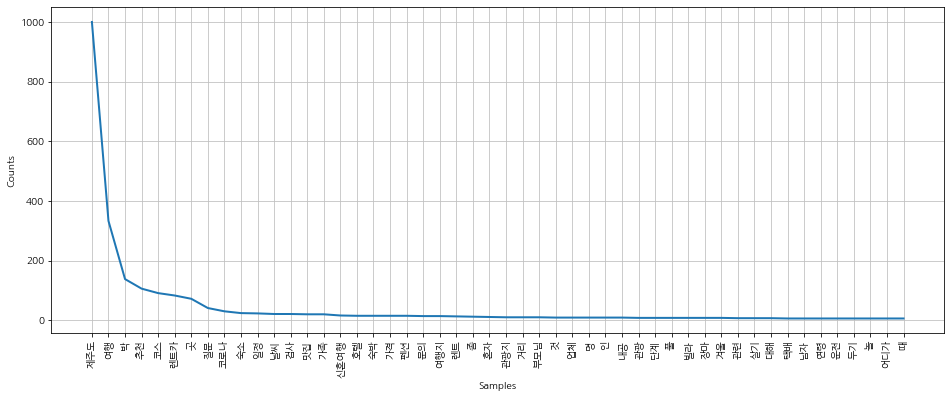

In [ ]:
# 텍스트에 대한 시각화 (상위 50개만 출력)
title_plot = nltk.Text(title_nouns)
plt.figure(figsize=(16,6))
title_plot.plot(50)
plt.show()

In [ ]:
from collections import Counter # jdk에서 제공해주는 라이브러리

title_cnt = Counter(title_nouns)
title_cnt

단어 빈도 수가 10건 이하인 데이터 걸러내기

In [ ]:
# 딕셔너리 구조를 튜플로 변경
title_tu = title_cnt.most_common()
title_tu[:5]

[('제주도', 1000), ('여행', 333), ('박', 138), ('추천', 106), ('코스', 91)]

In [ ]:
#title_rev = []
#for (key,num) in title_tu:
 # if num >= 11:
  #  title_rev.append((key,num))

title_rev = [ (key, num) for (key, num) in title_tu if num >= 5 and key != "제주도"]
title_rev[:10]

title_rev[:10]

[('여행', 333),
 ('박', 138),
 ('추천', 106),
 ('코스', 91),
 ('렌트카', 83),
 ('곳', 72),
 ('질문', 41),
 ('코로나', 30),
 ('숙소', 24),
 ('일정', 23)]

In [ ]:
! pip install WordCloud

워드클라우드로 시각화

In [ ]:
from wordcloud import WordCloud as WC
import matplotlib.pyplot as plt

path='/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

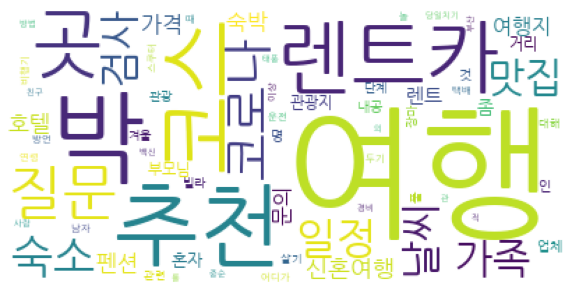

In [ ]:
wc_data = dict(title_rev)
wc1 = WC(font_path=path,background_color='white')
wc2 = wc1.generate_from_frequencies(wc_data)

plt.figure(figsize=(10,10))
plt.imshow(wc2)
plt.axis('Off') # 눈금선 해제
plt.show()

### 제주도 지식인 검색 데이터로 question과 answer를 이용하여 각각 워드 클라우드로 만들어라

In [ ]:
# df['question'] 데이터하나의 데이터(text)로 만들기
q_txt = ""

for txt in df['question']:
    q_txt += txt + "\n"

print(q_txt)

In [ ]:
# 정규화 표현
import re

q_txt = re.sub('[^0-9ㄱ-ㅣ가-힣 ]', ' ', q_txt)
q_txt

In [ ]:
okt = Okt()
q_nouns = okt.nouns(q_txt)
len(q_nouns)

20856

In [ ]:
len(set(q_nouns))

In [ ]:
q_cnt = Counter(q_nouns)
q_cnt

In [ ]:
q_tu = q_cnt.most_common()
q_tu[:5]

[('제주도', 2349), ('여행', 715), ('곳', 411), ('추천', 406), ('박', 374)]

In [ ]:
q_rev = [ (key, num) for (key, num) in q_tu if num >= 5
         and key != "제주도" and key != '곳' and key != '박' and key != '좀'
         and key != '요' and key != '제' and key != '명']
q_rev[:10]

q_rev[:10]

[('여행', 715),
 ('추천', 406),
 ('코스', 219),
 ('렌트카', 217),
 ('제', 197),
 ('숙소', 182),
 ('질문', 170),
 ('요', 155),
 ('맛집', 143),
 ('명', 142)]

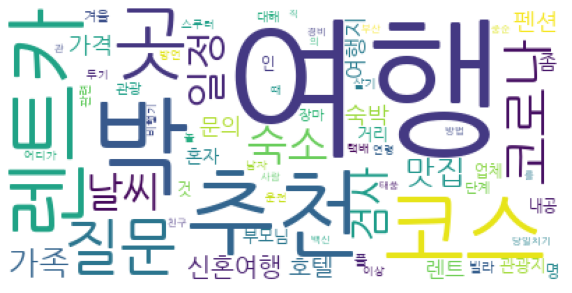

In [ ]:
wcQdata = dict(q_rev)
qwc1 = WC(font_path=path,background_color='white')
qwc2 = qwc1.generate_from_frequencies(wc_data)

plt.figure(figsize=(10,10))
plt.imshow(qwc2)
plt.axis('Off') # 눈금선 해제
plt.show()

In [ ]:
# df['answer'] 데이터하나의 데이터(text)로 만들기
a_txt = ""

for txt in df['answer']:
    a_txt += txt + "\n"

print(a_txt)

In [ ]:
# 정규화 표현
import re

a_txt = re.sub('[^0-9ㄱ-ㅣ가-힣 ]', ' ', a_txt)
a_txt

In [ ]:
okt = Okt()
a_nouns = okt.nouns(a_txt)
len(a_nouns)

956681